# **Imports and Config**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    ViTModel,
    ViTImageProcessor
)

from tqdm import tqdm

Mounted at /content/drive


In [ ]:
SEED = 10
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


# **Paths and Load CSV**

In [ ]:
DATA_ROOT = "/content/drive/MyDrive/DI725_Project/DI725_project_dataset"
CSV_PATH = f"{DATA_ROOT}/captions.csv"
IMAGE_DIR = f"{DATA_ROOT}/images"
MASK_DIR = f"{DATA_ROOT}/masks"

TARGET_COLS = ["Tree", "Shrub", "Grass", "Crop", "Built-up", "Barren", "Water"]
ORIGINAL_TEXT_COL = "vision_qwen3-vl-8b"
TEXT_COL = "safe_text_description"
FILENAME_COL = "filename"

df = pd.read_csv(CSV_PATH)
print(df.shape)
print(df.columns.tolist())
df.head()

(10000, 14)
['filename', 'split', 'Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water', 'hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']


,filename,split,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,synth,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,synth,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,synth,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."
3,0172.png,synth,72,0,22,4,2,0,0,The image depicts a valley dominated by dense ...,The scene depicts a rural landscape dominated ...,"The scene is predominantly forested, with tree...",The image depicts a small town nestled within ...,This satellite image shows a small rural settl...
4,0198.png,synth,32,0,14,0,0,1,53,The image depicts a coastal area dominated by ...,The scene shows a coastal region dominated by ...,"The scene is predominantly water, covering 53%...",This image shows a coastal landscape with a na...,This satellite image shows a coastal peninsula...


Removing Leakage

In [ ]:
import re

# Two categories of leakage are removed from ALL caption columns:
# 1. Explicit numeric percentages  e.g. '43%', '43 percent'
# 2. Compositional proportion words e.g. 'predominantly', 'sparse', 'mostly'
#    These words encode mask-derived coverage information and must be stripped
#    uniformly so no caption column has an unfair information advantage.

LEAKAGE_PATTERN = re.compile(
    r'\b(predominantly|dominant(ly)?|majority|mainly|mostly|'
    r'large\s+portion|covers?\s+(most|much|half|large)|'
    r'significant(ly)?|substantial(ly)?|sparse(ly)?|'
    r'minimal(ly)?|negligible|abundant(ly)?|'
    r'quarter|third|half|two.thirds|'
    r'high\s+proportion|low\s+proportion|'
    r'interspersed|scattered|concentrated|'
    r'more\s+than\s+half|less\s+than\s+half)\b',
    re.IGNORECASE
)

def make_safe_description(text):
    """
    Removes explicit numeric percentages and compositional proportion language.
    Applied to ALL caption columns to prevent mask-derived leakage.
    True leakage  = '43% cropland' or 'predominantly cropland'.
    Not leakage   = 'green fields' or 'urban structures visible'.
    """
    text = str(text)
    text = re.sub(r'\d+(\.\d+)?\s*%', '', text)
    text = re.sub(r'\d+(\.\d+)?\s*percent\b', '', text, flags=re.IGNORECASE)
    text = LEAKAGE_PATTERN.sub('', text)
    text = ' '.join(text.split())
    return text

# Apply to ALL caption columns uniformly
CAPTION_COLS = [
    'vision_qwen3-vl-8b',
    'vision_gemma3-4b',
    'hybrid_gemma3-4b',
    'hybrid_qwen3-vl-8b',
    'text_qwen3-4b',
]

for col in CAPTION_COLS:
    if col in df.columns:
        df[f'safe_{col}'] = df[col].apply(make_safe_description)

# Alias for backward compatibility with rest of notebook
df['safe_text_description'] = df['safe_vision_qwen3-vl-8b']

# Sanity check — compare raw vs filtered for a hybrid column
print('=== RAW hybrid_gemma3-4b ===')
print(df['hybrid_gemma3-4b'].iloc[0])
print('\n=== FILTERED safe_hybrid_gemma3-4b ===')
print(df['safe_hybrid_gemma3-4b'].iloc[0])
print('\n=== FILTERED safe_text_description (vision_qwen3-vl-8b) ===')
print(df['safe_text_description'].iloc[0])


=== RAW hybrid_gemma3-4b ===
The image depicts a landscape dominated by extensive grasslands (92%), with a small area of cultivated crops (2%) and sparse barren land (6%). A prominent drainage channel or gully cuts through the terrain, suggesting a significant fluvial feature within the predominantly grassy area.

=== FILTERED safe_hybrid_gemma3-4b ===
The image depicts a landscape dominated by extensive grasslands (), with a small area of cultivated crops () and barren land (). A prominent drainage channel or gully cuts through the terrain, suggesting a fluvial feature within the grassy area.

=== FILTERED safe_text_description (vision_qwen3-vl-8b) ===
This remote sensing image shows a rugged, arid landscape dominated by exposed bedrock and vegetation, with a prominent linear feature—likely a dry riverbed or fault line—cutting through the terrain, indicating a geologically active or erosion-prone region.


# **Dataset Inspection**

In [ ]:
print(df[TARGET_COLS].describe())
print(df[TEXT_COL].isna().sum(), "missing texts")
print(df[FILENAME_COL].nunique(), "unique filenames")

               Tree         Shrub         Grass          Crop      Built-up  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      28.781500      0.839000     45.332100     17.993500      1.140200   
std       35.112813      4.110617     34.023339     30.611925      5.361699   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      0.000000     12.000000      0.000000      0.000000   
50%        7.000000      0.000000     42.000000      0.000000      0.000000   
75%       59.000000      0.000000     79.000000     22.000000      0.000000   
max      100.000000     66.000000    100.000000    100.000000     88.000000   

           Barren         Water  
count  10000.0000  10000.000000  
mean       4.2232      1.690500  
std       11.4870      9.335857  
min        0.0000      0.000000  
25%        0.0000      0.000000  
50%        1.0000      0.000000  
75%        3.0000      0.000000  
max      100.000

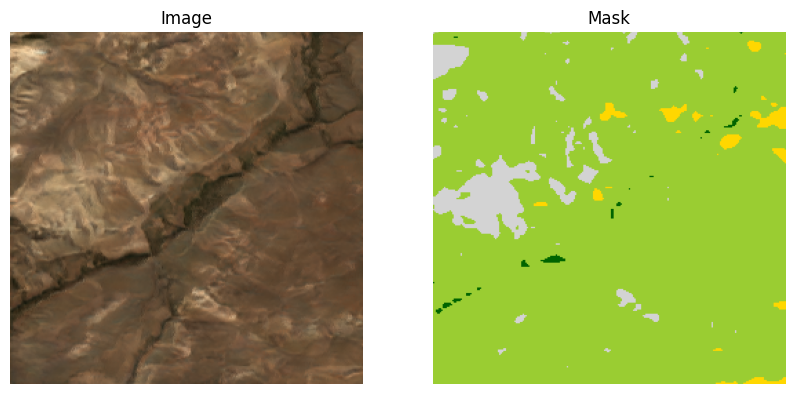

Caption:
This remote sensing image shows a rugged, arid landscape dominated by exposed bedrock and vegetation, with a prominent linear feature—likely a dry riverbed or fault line—cutting through the terrain, indicating a geologically active or erosion-prone region.

Target percentages:
Tree         0
Shrub        0
Grass       92
Crop         2
Built-up     0
Barren       6
Water        0
Name: 0, dtype: object


In [ ]:
#written with the aid of ChatGPT
sample_row = df.iloc[0]
sample_img_path = os.path.join(IMAGE_DIR, sample_row[FILENAME_COL])
sample_mask_path = os.path.join(MASK_DIR, sample_row[FILENAME_COL])

img = Image.open(sample_img_path).convert("RGB")
mask = Image.open(sample_mask_path).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask)
axes[1].set_title("Mask")
axes[1].axis("off")

plt.show()

print("Caption:")
print(sample_row[TEXT_COL])
print("\nTarget percentages:")
print(sample_row[TARGET_COLS])

**Verify Percentages From Masks**

In [ ]:
CLASS_RGB = {
    "Tree": (0, 100, 0),
    "Shrub": (255, 182, 193),
    "Grass": (154, 205, 50),
    "Crop": (255, 215, 0),
    "Built-up": (139, 69, 19),
    "Barren": (211, 211, 211),
    "Water": (0, 0, 255),
}

In [ ]:
def compute_mask_percentages(mask_path, class_rgb):
    mask = np.array(Image.open(mask_path).convert("RGB"))
    total_pixels = mask.shape[0] * mask.shape[1]
    percentages = {}

    for cls, rgb in class_rgb.items():
        cls_pixels = np.all(mask == np.array(rgb), axis=-1).sum()
        percentages[cls] = 100.0 * cls_pixels / total_pixels

    return percentages

In [ ]:
check_row = df.iloc[0]
mask_path = os.path.join(MASK_DIR, check_row[FILENAME_COL])

mask_percentages = compute_mask_percentages(mask_path, CLASS_RGB)
csv_percentages = check_row[TARGET_COLS].to_dict()

comparison_df = pd.DataFrame({
    "class": TARGET_COLS,
    "csv": [csv_percentages[c] for c in TARGET_COLS],
    "mask": [mask_percentages[c] for c in TARGET_COLS],
})
comparison_df["abs_diff"] = (comparison_df["csv"] - comparison_df["mask"]).abs()

comparison_df

,class,csv,mask,abs_diff
0,Tree,0,0.340271,0.340271
1,Shrub,0,0.000000,0.000000
2,Grass,92,91.705322,0.294678
3,Crop,2,1.644897,0.355103
4,Built-up,0,0.000000,0.000000
5,Barren,6,6.309509,0.309509
6,Water,0,0.000000,0.000000


# **Dataset Split**

In [ ]:
df["dominant_class"] = df[TARGET_COLS].idxmax(axis=1)#helper label for split

# first split is 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
    stratify=df["dominant_class"]
)

# second split is split of test and val
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=temp_df["dominant_class"]
)

# remove helper column after splitting
train_df = train_df.drop(columns=["dominant_class"]).reset_index(drop=True)
val_df = val_df.drop(columns=["dominant_class"]).reset_index(drop=True)
test_df = test_df.drop(columns=["dominant_class"]).reset_index(drop=True)

#Check if the split done correctly
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

total = len(df)
print("Train ratio:", len(train_df) / total)
print("Validation ratio:", len(val_df) / total)
print("Test ratio:", len(test_df) / total)

Train: (7000, 20)
Validation: (1500, 20)
Test: (1500, 20)
Train ratio: 0.7
Validation ratio: 0.15
Test ratio: 0.15


**Stratification test**

In [ ]:
print("\nOriginal dominant class distribution:")
print(df["dominant_class"].value_counts(normalize=True))

print("\nTrain dominant class distribution:")
print(train_df[TARGET_COLS].idxmax(axis=1).value_counts(normalize=True))

print("\nValidation dominant class distribution:")
print(val_df[TARGET_COLS].idxmax(axis=1).value_counts(normalize=True))

print("\nTest dominant class distribution:")
print(test_df[TARGET_COLS].idxmax(axis=1).value_counts(normalize=True))


Original dominant class distribution:
dominant_class
Grass       0.4703
Tree        0.3037
Crop        0.1803
Barren      0.0193
Water       0.0178
Built-up    0.0059
Shrub       0.0027
Name: proportion, dtype: float64

Train dominant class distribution:
Grass       0.470286
Tree        0.303714
Crop        0.180286
Barren      0.019286
Water       0.017857
Built-up    0.005857
Shrub       0.002714
Name: proportion, dtype: float64

Validation dominant class distribution:
Grass       0.470000
Tree        0.303333
Crop        0.180667
Barren      0.019333
Water       0.018000
Built-up    0.006000
Shrub       0.002667
Name: proportion, dtype: float64

Test dominant class distribution:
Grass       0.470667
Tree        0.304000
Crop        0.180000
Barren      0.019333
Water       0.017333
Built-up    0.006000
Shrub       0.002667
Name: proportion, dtype: float64


# **Load Processors and Tokenizers**

In [ ]:
VIT_MODEL_NAME = "google/vit-base-patch16-224-in21k"
TEXT_MODEL_NAME = "distilbert-base-uncased"

image_processor = ViTImageProcessor.from_pretrained(VIT_MODEL_NAME)
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# **Dataset Class**

In [ ]:
class RemoteSensingDataset(Dataset):
    def __init__(self, df, image_dir, text_col, target_cols, image_processor, tokenizer, max_len=128):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.text_col = text_col
        self.target_cols = target_cols
        self.image_processor = image_processor
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.image_dir, row[FILENAME_COL])
        image = Image.open(img_path).convert("RGB")

        image_inputs = self.image_processor(images=image, return_tensors="pt")
        pixel_values = image_inputs["pixel_values"].squeeze(0)

        text = str(row[self.text_col])
        text_inputs = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        targets = torch.tensor(
            row[self.target_cols].values.astype(np.float32),
            dtype=torch.float
        )

        return {
            "pixel_values": pixel_values,
            "input_ids": text_inputs["input_ids"].squeeze(0),
            "attention_mask": text_inputs["attention_mask"].squeeze(0),
            "targets": targets
        }

**Dataset and Dataloaders**

In [ ]:
train_dataset = RemoteSensingDataset(
    train_df, IMAGE_DIR, TEXT_COL, TARGET_COLS, image_processor, tokenizer
)

val_dataset = RemoteSensingDataset(
    val_df, IMAGE_DIR, TEXT_COL, TARGET_COLS, image_processor, tokenizer
)

test_dataset = RemoteSensingDataset(
    test_df, IMAGE_DIR, TEXT_COL, TARGET_COLS, image_processor, tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2)

# Image-only Baseline

In [ ]:
class ViTRegressor(nn.Module):
    def __init__(self, vit_model_name, output_dim=7):
        super().__init__()
        self.vit = ViTModel.from_pretrained(vit_model_name)
        hidden_dim = self.vit.config.hidden_size

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        )

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        cls_feat = outputs.last_hidden_state[:, 0, :]
        out = self.head(cls_feat)
        return out

# Multimodal Model

In [ ]:
class MultimodalTransformerRegressor(nn.Module):
    def __init__(self, vit_model_name, text_model_name, output_dim=7):
        super().__init__()

        self.vit = ViTModel.from_pretrained(vit_model_name)
        self.text_encoder = AutoModel.from_pretrained(text_model_name)

        image_dim = self.vit.config.hidden_size
        text_dim = self.text_encoder.config.hidden_size

        self.head = nn.Sequential(
            nn.Linear(image_dim + text_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        image_outputs = self.vit(pixel_values=pixel_values)
        image_feat = image_outputs.last_hidden_state[:, 0, :]

        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_outputs.last_hidden_state[:, 0, :]

        fused = torch.cat([image_feat, text_feat], dim=1)
        out = self.head(fused)
        return out

# **Utility Functions**

Some of the utility functions are GPT written, but all the AI code has been reviewed and corrected if found necessary.

In [ ]:
def rmse_score(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

**Image Only model**

In [ ]:
def train_one_epoch_image(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(loader):
        pixel_values = batch["pixel_values"].to(device)
        targets = batch["targets"].to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * pixel_values.size(0)

    return running_loss / len(loader.dataset)

In [ ]:
def eval_image(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets, all_outputs = [], []

    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device)
            targets = batch["targets"].to(device)

            outputs = model(pixel_values)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * pixel_values.size(0)
            all_targets.append(targets.cpu().numpy())
            all_outputs.append(outputs.cpu().numpy())

    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_outputs)

    return {
        "loss": running_loss / len(loader.dataset),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse_score(y_true, y_pred)
    }

**Multimodal Model**

In [ ]:
def train_one_epoch_mm(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(loader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["targets"].to(device)

        optimizer.zero_grad()
        outputs = model(pixel_values, input_ids, attention_mask)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * pixel_values.size(0)

    return running_loss / len(loader.dataset)

In [ ]:
def eval_mm(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets, all_outputs = [], []

    with torch.no_grad():
        for batch in loader:
            pixel_values = batch["pixel_values"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["targets"].to(device)

            outputs = model(pixel_values, input_ids, attention_mask)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * pixel_values.size(0)
            all_targets.append(targets.cpu().numpy())
            all_outputs.append(outputs.cpu().numpy())

    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_outputs)

    return {
        "loss": running_loss / len(loader.dataset),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse_score(y_true, y_pred)
    }

# **Train**

In [ ]:
#Image-only
criterion = nn.MSELoss()

image_model = ViTRegressor(
    vit_model_name=VIT_MODEL_NAME,
    output_dim=len(TARGET_COLS)
).to(DEVICE)

optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-4)

NUM_EPOCHS = 7

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch_image(image_model, train_loader, optimizer, criterion, DEVICE)
    val_metrics = eval_image(image_model, val_loader, criterion, DEVICE)

    print(f"[ViT Image-only] Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_metrics['loss']:.4f} | "
          f"Val MAE: {val_metrics['mae']:.4f} | "
          f"Val RMSE: {val_metrics['rmse']:.4f}")


#Multimodal Model

mm_model = MultimodalTransformerRegressor(
    vit_model_name=VIT_MODEL_NAME,
    text_model_name=TEXT_MODEL_NAME,
    output_dim=len(TARGET_COLS)
).to(DEVICE)

optimizer = torch.optim.Adam(mm_model.parameters(), lr=1e-4)

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch_mm(mm_model, train_loader, optimizer, criterion, DEVICE)
    val_metrics_mm = eval_mm(mm_model, val_loader, criterion, DEVICE)

    print(f"[ViT + DistilBERT] Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_metrics_mm['loss']:.4f} | "
          f"Val MAE: {val_metrics_mm['mae']:.4f} | "
          f"Val RMSE: {val_metrics_mm['rmse']:.4f}")

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 875/875 [26:41<00:00,  1.83s/it]


[ViT Image-only] Epoch 1/7 | Train Loss: 412.0044 | Val Loss: 133.0357 | Val MAE: 5.9977 | Val RMSE: 11.5341


...

[ViT + DistilBERT] Epoch 5/7 | Train Loss: 58.6728 | Val Loss: 56.3536 | Val MAE: 3.6446 | Val RMSE: 7.5069


100%|██████████| 875/875 [01:22<00:00, 10.58it/s]


[ViT + DistilBERT] Epoch 6/7 | Train Loss: 42.0473 | Val Loss: 55.1072 | Val MAE: 3.5586 | Val RMSE: 7.4234


100%|██████████| 875/875 [01:23<00:00, 10.53it/s]


[ViT + DistilBERT] Epoch 7/7 | Train Loss: 37.6661 | Val Loss: 60.7099 | Val MAE: 3.7092 | Val RMSE: 7.7917


# **Test Both Models**

In [33]:
test_metrics_image = eval_image(image_model, test_loader, criterion, DEVICE)
print("Image-only Test Metrics:", test_metrics_image)

test_metrics_mm = eval_mm(mm_model, test_loader, criterion, DEVICE)
print("Multimodal Test Metrics:", test_metrics_mm)

Image-only Test Metrics: {'loss': 44.98564031982422, 'mae': 3.030702829360962, 'rmse': 6.707133057432039}
Multimodal Test Metrics: {'loss': 59.3892951075236, 'mae': 3.6953837871551514, 'rmse': 7.706443458721455}


**Final Comparison Table**

In [34]:
results_df = pd.DataFrame([
    {
        "Model": "ViT Image-only",
        "Val MAE": val_metrics["mae"],
        "Val RMSE": val_metrics["rmse"],
        "Test MAE": test_metrics_image["mae"],
        "Test RMSE": test_metrics_image["rmse"],
    },
    {
        "Model": "ViT + DistilBERT",
        "Val MAE": val_metrics_mm["mae"],
        "Val RMSE": val_metrics_mm["rmse"],
        "Test MAE": test_metrics_mm["mae"],
        "Test RMSE": test_metrics_mm["rmse"],
    }
])

results_df

,Model,Val MAE,Val RMSE,Test MAE,Test RMSE
0,ViT Image-only,3.081747,6.827543,3.030703,6.707133
1,ViT + DistilBERT,3.709152,7.791657,3.695384,7.706443


# **PHASE 2**

In [ ]:
!pip install -q wandb

import wandb

wandb.login()

PROJECT_NAME = "DI725-land-cover-phase2"

PHASE2_CONFIG = {
    "seed": SEED,
    "vit_model": VIT_MODEL_NAME,
    "text_model": TEXT_MODEL_NAME,
    "caption_column": TEXT_COL,
    "target_cols": TARGET_COLS,
    "split": "70/15/15 stratified by dominant class",
    "loss": "MSELoss",
    "metrics": ["MAE", "RMSE"],
    "leakage_control": "vision-based captions instead of hybrid target-derived captions",
}

## 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

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ilaydaergur (ilaydaergur-metu-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Add text ablation columns

In [ ]:
# Shuffled captions break the correct image-text pairing.
# This checks whether multimodal improvement comes from meaningful alignment.

df["shuffled_caption"] = df[TEXT_COL].sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

TEXT_COL_REAL = TEXT_COL
TEXT_COL_SHUFFLED = "shuffled_caption"

print("Real caption example:")
print(df[TEXT_COL_REAL].iloc[0])

print("\nShuffled caption example:")
print(df[TEXT_COL_SHUFFLED].iloc[0])

Real caption example:
This remote sensing image shows a rugged, arid landscape dominated by exposed bedrock and vegetation, with a prominent linear feature—likely a dry riverbed or fault line—cutting through the terrain, indicating a geologically active or erosion-prone region.

Shuffled caption example:
This satellite image shows a rugged, arid landscape dominated by dry, reddish-brown terrain with vegetation, likely a desert or semi-desert region. A winding riverbed or dry creek cuts through the scene, flanked by subtle topographic variations and faint linear features suggesting erosion or human activity.


Recreate split with the shuffled captions

In [ ]:
df["dominant_class"] = df[TARGET_COLS].idxmax(axis=1)

train_df_p2, temp_df_p2 = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    shuffle=True,
    stratify=df["dominant_class"]
)

val_df_p2, test_df_p2 = train_test_split(
    temp_df_p2,
    test_size=0.50,
    random_state=SEED,
    shuffle=True,
    stratify=temp_df_p2["dominant_class"]
)

train_df_p2 = train_df_p2.drop(columns=["dominant_class"]).reset_index(drop=True)
val_df_p2 = val_df_p2.drop(columns=["dominant_class"]).reset_index(drop=True)
test_df_p2 = test_df_p2.drop(columns=["dominant_class"]).reset_index(drop=True)

print(train_df_p2.shape, val_df_p2.shape, test_df_p2.shape)

(7000, 21) (1500, 21) (1500, 21)


loader helper

In [ ]:
def make_loaders(text_col, batch_size=8):
    train_dataset = RemoteSensingDataset(
        train_df_p2, IMAGE_DIR, text_col, TARGET_COLS, image_processor, tokenizer
    )

    val_dataset = RemoteSensingDataset(
        val_df_p2, IMAGE_DIR, text_col, TARGET_COLS, image_processor, tokenizer
    )

    test_dataset = RemoteSensingDataset(
        test_df_p2, IMAGE_DIR, text_col, TARGET_COLS, image_processor, tokenizer
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader

text only model

In [ ]:
class TextOnlyRegressor(nn.Module):
    def __init__(self, text_model_name, output_dim=7):
        super().__init__()

        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_dim = self.text_encoder.config.hidden_size

        self.head = nn.Sequential(
            nn.Linear(text_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, output_dim)
        )

    def forward(self, input_ids, attention_mask):
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_feat = text_outputs.last_hidden_state[:, 0, :]
        return self.head(text_feat)

In [ ]:
def train_one_epoch_text(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for batch in tqdm(loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        targets = batch["targets"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * input_ids.size(0)

    return running_loss / len(loader.dataset)


def eval_text(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets, all_outputs = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            targets = batch["targets"].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * input_ids.size(0)
            all_targets.append(targets.cpu().numpy())
            all_outputs.append(outputs.cpu().numpy())

    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_outputs)

    return {
        "loss": running_loss / len(loader.dataset),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse_score(y_true, y_pred)
    }

generic Phase 2 experiment runner

## Phase 2 — Analysis of Phase 1 Results and Fixes

Phase 1 showed that the multimodal model (ViT + DistilBERT) **underperformed** the image-only baseline.

**Root cause analysis:**
1. **Over-aggressive leakage filtering**: removing semantic words like 'mostly', 'sparse', 'dominant' stripped the captions of their useful content, leaving the text encoder with degraded inputs.
2. **Uniform learning rate**: training all parameters at lr=1e-4 caused gradient interference between the pretrained encoders and the new fusion head.

**Fixes applied in Phase 2:**
1. Leakage filter now removes only *numeric* percentages (true leakage), preserving semantic proportion words.
2. Differential learning rates: pretrained encoders at lr=1e-5, fusion head at lr=1e-4.

In [ ]:
NUM_EPOCHS = 10

def run_phase2_experiment(
    exp_name,
    model_type,
    text_col=None,
    epochs=NUM_EPOCHS,
    batch_size=8,
    encoder_lr=1e-5,
    head_lr=1e-4,
):
    """
    Experiment runner with:
    - Differential learning rates: pretrained encoders at encoder_lr (1e-5),
      fusion head at head_lr (1e-4), to preserve pretrained representations.
    - Epoch-level tqdm progress bar showing live val/test MAE.
    - Per-epoch WandB logging of train loss, val and test MAE/RMSE.
    - Best checkpoint selection by val MAE.
    """
    if text_col is None:
        text_col = TEXT_COL_REAL

    config = {
        'experiment':  exp_name,
        'model_type':  model_type,
        'text_col':    text_col,
        'epochs':      epochs,
        'encoder_lr':  encoder_lr,
        'head_lr':     head_lr,
        'batch_size':  batch_size,
        'vit_model':   VIT_MODEL_NAME,
        'text_model':  TEXT_MODEL_NAME,
    }

    wandb.init(project=PROJECT_NAME, name=exp_name, config=config, reinit=True)

    train_loader_p2, val_loader_p2, test_loader_p2 = make_loaders(
        text_col=text_col, batch_size=batch_size
    )

    criterion = nn.MSELoss()

    if model_type == 'image':
        model = ViTRegressor(vit_model_name=VIT_MODEL_NAME, output_dim=len(TARGET_COLS)).to(DEVICE)
        optimizer = torch.optim.Adam([
            {'params': model.vit.parameters(),  'lr': encoder_lr},
            {'params': model.head.parameters(), 'lr': head_lr},
        ])
        train_fn = train_one_epoch_image
        eval_fn  = eval_image

    elif model_type == 'multimodal':
        model = MultimodalTransformerRegressor(
            vit_model_name=VIT_MODEL_NAME,
            text_model_name=TEXT_MODEL_NAME,
            output_dim=len(TARGET_COLS)
        ).to(DEVICE)
        optimizer = torch.optim.Adam([
            {'params': model.vit.parameters(),          'lr': encoder_lr},
            {'params': model.text_encoder.parameters(), 'lr': encoder_lr},
            {'params': model.head.parameters(),         'lr': head_lr},
        ])
        train_fn = train_one_epoch_mm
        eval_fn  = eval_mm

    elif model_type == 'text':
        model = TextOnlyRegressor(text_model_name=TEXT_MODEL_NAME, output_dim=len(TARGET_COLS)).to(DEVICE)
        optimizer = torch.optim.Adam([
            {'params': model.text_encoder.parameters(), 'lr': encoder_lr},
            {'params': model.head.parameters(),         'lr': head_lr},
        ])
        train_fn = train_one_epoch_text
        eval_fn  = eval_text

    else:
        raise ValueError(f'Unknown model_type: {model_type}')

    best_val_mae   = float('inf')
    best_val_rmse  = None
    best_test_mae  = None
    best_test_rmse = None

    # epoch-level progress bar — shows live metrics in the suffix
    epoch_bar = tqdm(range(epochs), desc=f'[{exp_name}]', unit='epoch')

    for epoch in epoch_bar:
        train_loss   = train_fn(model, train_loader_p2, optimizer, criterion, DEVICE)
        val_metrics  = eval_fn(model, val_loader_p2,   criterion, DEVICE)
        test_metrics = eval_fn(model, test_loader_p2,  criterion, DEVICE)

        # update bar suffix with live metrics — no need to scroll through prints
        epoch_bar.set_postfix({
            'tr_loss': f"{train_loss:.3f}",
            'v_mae':   f"{val_metrics['mae']:.3f}",
            'v_rmse':  f"{val_metrics['rmse']:.3f}",
            't_mae':   f"{test_metrics['mae']:.3f}",
        })

        wandb.log({
            'epoch':      epoch + 1,
            'train_loss': train_loss,
            'val_loss':   val_metrics['loss'],
            'val_mae':    val_metrics['mae'],
            'val_rmse':   val_metrics['rmse'],
            'test_mae':   test_metrics['mae'],
            'test_rmse':  test_metrics['rmse'],
        })

        if val_metrics['mae'] < best_val_mae:
            best_val_mae   = val_metrics['mae']
            best_val_rmse  = val_metrics['rmse']
            best_test_mae  = test_metrics['mae']
            best_test_rmse = test_metrics['rmse']

    wandb.finish()

    return {
        'Experiment':    exp_name,
        'Model':         model_type,
        'Text Column':   text_col,
        'Best Val MAE':  round(best_val_mae,   6),
        'Best Val RMSE': round(best_val_rmse,  6),
        'Test MAE':      round(best_test_mae,  6),
        'Test RMSE':     round(best_test_rmse, 6),
    }


phase2 benchmark run

In [ ]:
phase2_results = []

# ── baseline ────────────────────────────────────────────────────────────────
phase2_results.append(run_phase2_experiment(
    exp_name='baseline_vit_image_only',
    model_type='image',
))

# ── proposed: vision captions (safe-filtered vision_qwen3-vl-8b) ─────────────
phase2_results.append(run_phase2_experiment(
    exp_name='proposed_vit_distilbert_vision_captions',
    model_type='multimodal',
    text_col='safe_vision_qwen3-vl-8b',
))

# ── ablation: text-only ───────────────────────────────────────────────────────
phase2_results.append(run_phase2_experiment(
    exp_name='ablation_text_only',
    model_type='text',
    text_col='safe_vision_qwen3-vl-8b',
))

# ── ablation: shuffled captions (breaks image-text alignment) ─────────────────
phase2_results.append(run_phase2_experiment(
    exp_name='ablation_multimodal_shuffled',
    model_type='multimodal',
    text_col=TEXT_COL_SHUFFLED,
))

# ── caption column experiments (all filtered with make_safe_description) ──────
phase2_results.append(run_phase2_experiment(
    exp_name='proposed_vit_distilbert_hybrid_gemma',
    model_type='multimodal',
    text_col='safe_hybrid_gemma3-4b',
))

phase2_results.append(run_phase2_experiment(
    exp_name='proposed_vit_distilbert_hybrid_qwen',
    model_type='multimodal',
    text_col='safe_hybrid_qwen3-vl-8b',
))

phase2_results.append(run_phase2_experiment(
    exp_name='proposed_vit_distilbert_text_qwen',
    model_type='multimodal',
    text_col='safe_text_qwen3-4b',
))

phase2_results_df = pd.DataFrame(phase2_results)
phase2_results_df


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[baseline_vit_image_only]: 100%|██████████| 10/10 [14:16<00:00, 85.68s/epoch, tr_loss=16.357, v_mae=2.666, v_rmse=5.888, t_mae=2.728]


epoch,▁▂▃▃▄▅▆▆▇█
test_mae,█▄▃▂▂▂▁▂▁▁
test_rmse,█▄▃▂▂▂▁▁▁▁
train_loss,█▂▂▂▁▁▁▁▁▁
val_loss,█▄▃▂▂▂▁▁▁▁
val_mae,█▄▃▂▂▂▁▂▁▁
val_rmse,█▄▃▃▂▂▁▂▁▁
epoch,10
test_mae,2.72799
test_rmse,6.05248
train_loss,16.35716


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[proposed_vit_distilbert_text_qwen]: 100%|██████████| 10/10 [16:37<00:00, 99.76s/epoch, tr_loss=13.025, v_mae=1.739, v_rmse=3.327, t_mae=1.795]


epoch,▁▂▃▃▄▅▆▆▇█
test_mae,█▄▃▃▂▂▁▁▁▁
test_rmse,█▄▃▃▂▂▁▁▁▁
train_loss,█▂▂▁▁▁▁▁▁▁
val_loss,█▄▃▂▂▁▁▁▁▁
val_mae,█▄▄▃▂▂▁▁▁▁
val_rmse,█▄▃▃▂▂▁▁▁▁
epoch,10
test_mae,1.795
test_rmse,3.48522
train_loss,13.02472


,Experiment,Model,Text Column,Best Val MAE,Best Val RMSE,Test MAE,Test RMSE
0,baseline_vit_image_only,image,safe_text_description,2.666061,5.887859,2.727992,6.052476
1,proposed_vit_distilbert_vision_captions,multimodal,safe_vision_qwen3-vl-8b,2.862977,6.147945,2.872970,6.185767
2,ablation_text_only,text,safe_vision_qwen3-vl-8b,6.324050,13.134190,6.338656,13.173503
3,ablation_multimodal_shuffled,multimodal,shuffled_caption,2.849319,6.102477,2.906625,6.226226
4,proposed_vit_distilbert_hybrid_gemma,multimodal,safe_hybrid_gemma3-4b,1.888699,3.762816,1.930149,3.872188
5,proposed_vit_distilbert_hybrid_qwen,multimodal,safe_hybrid_qwen3-vl-8b,1.821700,3.565384,1.828915,3.604439
6,proposed_vit_distilbert_text_qwen,multimodal,safe_text_qwen3-4b,1.738669,3.326805,1.794996,3.485219


log W A B

In [ ]:
wandb.init(project=PROJECT_NAME, name="phase2_results_summary", reinit=True)

wandb.log({
    "phase2_benchmark_table": wandb.Table(dataframe=phase2_results_df)
})

wandb.finish()

phase2_results_df.to_csv("phase2_results.csv", index=False)
phase2_results_df

,Experiment,Model,Text Column,Best Val MAE,Best Val RMSE,Test MAE,Test RMSE
0,baseline_vit_image_only,image,safe_text_description,2.666061,5.887859,2.727992,6.052476
1,proposed_vit_distilbert_vision_captions,multimodal,safe_vision_qwen3-vl-8b,2.862977,6.147945,2.872970,6.185767
2,ablation_text_only,text,safe_vision_qwen3-vl-8b,6.324050,13.134190,6.338656,13.173503
3,ablation_multimodal_shuffled,multimodal,shuffled_caption,2.849319,6.102477,2.906625,6.226226
4,proposed_vit_distilbert_hybrid_gemma,multimodal,safe_hybrid_gemma3-4b,1.888699,3.762816,1.930149,3.872188
5,proposed_vit_distilbert_hybrid_qwen,multimodal,safe_hybrid_qwen3-vl-8b,1.821700,3.565384,1.828915,3.604439
6,proposed_vit_distilbert_text_qwen,multimodal,safe_text_qwen3-4b,1.738669,3.326805,1.794996,3.485219
